# Lesson 03 · Credible intervals

**Source:** *Introduction to Empirical Bayes: Examples from Baseball Statistics*, David Robinson (2017), Chapter 4 (pp. 28–34)

**Question:** A point estimate isn't enough. How uncertain is each player's average, and how does a Bayesian credible interval compare with a classical confidence interval?

**Goal:** Compute each player's posterior Beta(α₁, β₁) and its credible interval, then compare with Clopper–Pearson and Jeffreys confidence intervals.

**Contents**

1. Setup: shrunken estimates
2. Each player's posterior distribution
3. Credible intervals
4. Credible vs confidence intervals
5. Exercises

**Tags:** `credible-intervals` `confidence-intervals` `posterior` `clopper-pearson` `jeffreys-prior` `uncertainty`

**Before you start:** Lesson 02 (and ideally its saved prior).

*How this notebook works:* each **Your turn** prompt is followed by an empty cell for your code. **Check** boxes give values to compare against; they come from the book, and your numbers can differ slightly because the Lahman data now runs through more recent seasons. **Reflect** prompts are for short written answers. Every prompt is numbered *lesson.section.question* (for example **2.3.1**), so you can refer to it; empty code cells and answer cells carry the same number.

In [1]:
# --- Setup: run this cell first ------------------------------------------
# Windows + conda: put the environment's DLL folders on PATH, so plotting
# can't crash the kernel when Jupyter wasn't started from the activated env.
import os, sys
for sub in ["Library\\mingw-w64\\bin", "Library\\usr\\bin", "Library\\bin", "Scripts", "bin"]:
    p = os.path.join(sys.prefix, sub)
    if os.path.isdir(p) and p not in os.environ["PATH"]:
        os.environ["PATH"] = p + os.pathsep + os.environ["PATH"]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats, optimize, special

import eb_data   # helpers in this folder: loading the Lahman data, saving results

rng = np.random.default_rng(2017)
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (7, 4)
print(f"numpy {np.__version__} | pandas {pd.__version__} | scipy {scipy.__version__}")

career = eb_data.career(pitcher_rule=None)   # Chapters 3-5 drop anyone who ever pitched
alpha0, beta0 = eb_data.load_prior()          # your Lesson 02 prior, or the book's
print(f"{len(career):,} players | prior alpha0 = {alpha0:.1f}, beta0 = {beta0:.1f}")

numpy 2.5.3 | pandas 3.0.6 | scipy 1.18.1
11,725 players | prior alpha0 = 95.3, beta0 = 271.5


## 1. Setup: shrunken estimates

The posterior for player $i$ is Beta($\alpha_{1,i}$, $\beta_{1,i}$) with $\alpha_{1,i} = \alpha_0 + H_i$ and $\beta_{1,i} = \beta_0 + AB_i - H_i$.

**3.1.1 · Your turn.** Add columns `eb_estimate`, `alpha1` and `beta1` to `career`.

In [2]:
# 3.1.1 · Your code here
career['alpha1'] = alpha0 + career.H
career['beta1'] = beta0 + career.AB - career.H
career['eb_estimate'] = stats.beta(career.alpha1, career.beta1).mean()
career.head()

,playerID,name,H,AB,average,alpha1,beta1,eb_estimate
0,aaronha01,Hank Aaron,3771,12364,0.3050,3866.3306,8864.4864,0.3037
1,aaronto01,Tommie Aaron,216,944,0.2288,311.3306,999.4864,0.2375
2,abadan01,Andy Abad,2,21,0.0952,97.3306,290.4864,0.2510
3,abadijo01,John Abadie,11,49,0.2245,106.3306,309.4864,0.2557
4,abbated01,Ed Abbaticchio,772,3044,0.2536,867.3306,2543.4864,0.2543


## 2. Each player's posterior distribution

The book uses seven players from the 1998 Yankees. Their IDs: `brosisc01, jeterde01, knoblch01, martiti02, posadjo01, strawda01, willibe02`.

**3.2.1 · Your turn.** Plot the posterior density of each of the seven, plus the prior as a dashed line.

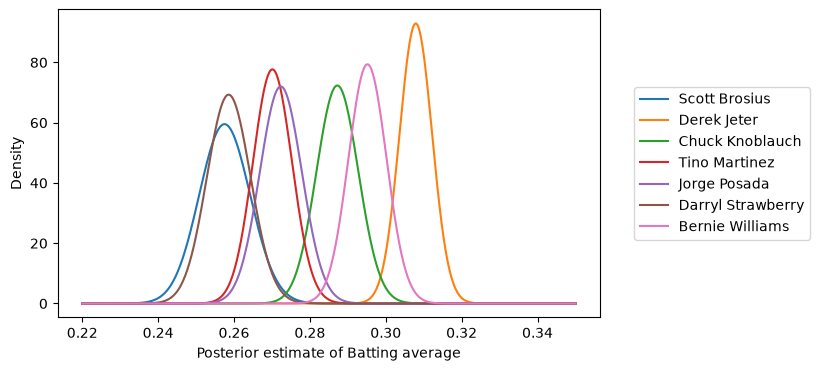

In [3]:
# 3.2.1 · Your code here
x = np.linspace(0.22, 0.35, 700)
yanks = ['brosisc01', 'jeterde01', 'knoblch01', 'martiti02', 'posadjo01', 'strawda01', 'willibe02']
for yank in yanks:
    player = career.loc[career['playerID'] == yank]
    label = player['name']
    post_player = stats.beta(player.alpha1, player.beta1).pdf(x)
    plt.plot(x, post_player, label = label)
plt.xlabel('Posterior estimate of Batting average')
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.show()
    

**3.2.2 · Reflect.** The empirical Bayes estimate is the posterior *mean*. The peak of the curve is the *mode*, $(\alpha-1)/(\alpha+\beta-2)$. Why are the two almost identical here? When would they differ noticeably?

*3.2.2 · Your answer:*

Means and modes are typically identical or close if the distribution is roughly symmetric. means and modes will begin to diverge with significant skew in either direction.

## 3. Credible intervals

A 95% credible interval holds the middle 95% of the posterior: from its 2.5% quantile to its 97.5% quantile. `stats.beta.ppf` works on whole arrays at once.

**3.3.1 · Your turn.** Add `low` and `high` columns (the 95% credible interval) for every player. Show the seven Yankees.

In [4]:
# 3.3.1 · Your code here
career['low'] = stats.beta(career.alpha1, career.beta1).ppf(0.025)
career['high'] = stats.beta(career.alpha1, career.beta1).ppf(0.975)

yankees = career[career['playerID'].isin(yanks)]
yankees

,playerID,name,H,AB,average,alpha1,beta1,eb_estimate,low,high
1209,brosisc01,Scott Brosius,1001,3889,0.2574,1096.3306,3159.4864,0.2576,0.2446,0.2709
5201,jeterde01,Derek Jeter,3465,11195,0.3095,3560.3306,8001.4864,0.3079,0.2996,0.3164
5733,knoblch01,Chuck Knoblauch,1839,6366,0.2889,1934.3306,4798.4864,0.2873,0.2766,0.2982
6632,martiti02,Tino Martinez,1925,7111,0.2707,2020.3306,5457.4864,0.2702,0.2602,0.2803
8421,posadjo01,Jorge Posada,1664,6092,0.2731,1759.3306,4699.4864,0.2724,0.2616,0.2833
10193,strawda01,Darryl Strawberry,1401,5418,0.2586,1496.3306,4288.4864,0.2587,0.2475,0.2700
11310,willibe02,Bernie Williams,2336,7869,0.2969,2431.3306,5804.4864,0.2952,0.2854,0.3051


> **Check:** Derek Jeter (3465 H / 11195 AB): about (0.300, 0.316).

**3.3.2 · Your turn.** Plot the seven intervals as a horizontal error-bar chart, sorted by estimate, with a vertical dashed line at the prior mean.

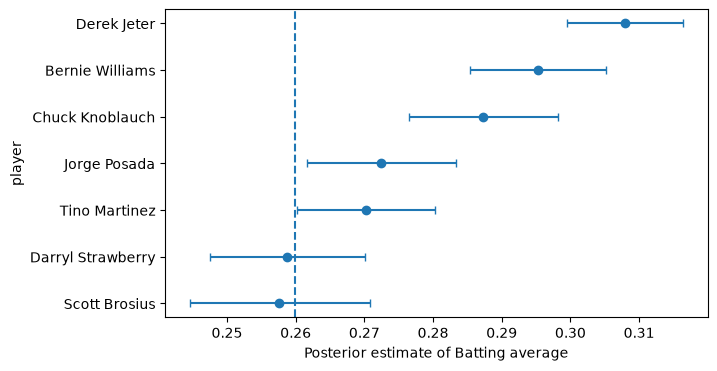

In [33]:
# 3.3.2 · Your code here
yankees = yankees.sort_values('eb_estimate', ascending = False)

y = np.arange(len(yankees), 0, -1)

xerr = [yankees.eb_estimate - yankees.low,     
        yankees.high - yankees.eb_estimate]  

plt.errorbar(yankees.eb_estimate, y, xerr = xerr, fmt="o", capsize=3)
plt.yticks(y, yankees['name'].tolist())
plt.axvline(alpha0 / (alpha0 + beta0), ls="--")
plt.xlabel('Posterior estimate of Batting average')
plt.ylabel('Player')
plt.show()

## 4. Credible vs confidence intervals

Two classic confidence intervals for a binomial proportion turn out to use beta quantiles too. For $x$ successes in $n$ trials, a 95% interval is `[beta.ppf(0.025, a_low, b_low), beta.ppf(0.975, a_high, b_high)]` with:

| Method | $a_{low}$ | $b_{low}$ | $a_{high}$ | $b_{high}$ |
|---|---|---|---|---|
| Credible interval | $\alpha_0 + x$ | $\beta_0 + n - x$ | $\alpha_0 + x$ | $\beta_0 + n - x$ |
| Jeffreys | $\tfrac12 + x$ | $\tfrac12 + n - x$ | $\tfrac12 + x$ | $\tfrac12 + n - x$ |
| Clopper–Pearson | $x$ | $n - x + 1$ | $x + 1$ | $n - x$ |

So the Jeffreys interval is a credible interval with the nearly flat prior Beta(½, ½).

**3.4.1 · Your turn.** Write `clopper_pearson(x, n)` and `jeffreys(x, n)` from the table. Check the first against `stats.binomtest(10, 30).proportion_ci(method="exact")`.

In [16]:
# 3.4.1 · Your code here

def clopper_pearson(x, n):
    a_low = x
    b_low = n - x + 1
    a_high = x + 1
    b_high = n - x
    pct_low = stats.beta(a_low, b_low).ppf(0.025)
    pct_high = stats.beta(a_high, b_high).ppf(0.975)
    return [pct_low, pct_high]

def jeffreys(x, n):
    a = 0.5 + x
    b = 0.5 + n - x 
    pct_low = stats.beta(a, b).ppf(0.025)
    pct_high = stats.beta(a, b).ppf(0.975)
    return [pct_low, pct_high]

clopper_pearson(10, 30), jeffreys(10, 30), stats.binomtest(10, 30).proportion_ci(method="exact")

([np.float64(0.17287422152603915), np.float64(0.5281200447898806)],
 [np.float64(0.18597875024779506), np.float64(0.5111481492171623)],
 ConfidenceInterval(low=np.float64(0.1728742215260392), high=np.float64(0.5281200447898805)))

> **Check:** Clopper–Pearson for 10/30 ≈ (0.173, 0.528).

**3.4.2 · Your turn.** Sample 20 random players (`career.sample(20, random_state=...)`), sort them by AB, and plot the credible interval and the Clopper–Pearson interval for each side by side.

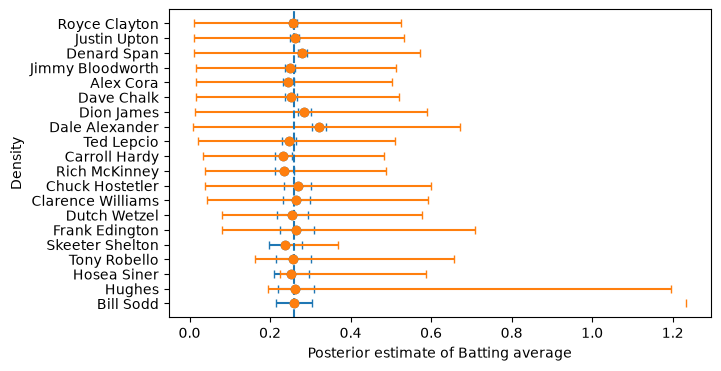

In [32]:
# 3.4.2 · Your code here
sample20 = career.sample(20, random_state = 42)
sample20 = sample20.sort_values('AB', ascending = False)
sample20.head()

y = np.arange(len(sample20), 0, -1)

xerr_CI = [sample20.eb_estimate - sample20.low,     
        sample20.high - sample20.eb_estimate]  


xerr_CPI = clopper_pearson(sample20.H, sample20.AB)

plt.errorbar(sample20.eb_estimate, y, xerr = xerr_CI, fmt="o", capsize=3)
plt.errorbar(sample20.eb_estimate, y, xerr = xerr_CPI, fmt="o", capsize=3)
plt.yticks(y, sample20['name'].tolist())
plt.axvline(alpha0 / (alpha0 + beta0), ls="--")
plt.xlabel('Posterior estimate of Batting average')
plt.ylabel('Player')
plt.show()

**3.4.3 · Reflect.** When do the credible and confidence intervals agree, and when do they differ? Answer in terms of how much information the data carry compared with the prior.

*3.4.3 · Your answer:*
With increasing evidence, credible and confidence intervals start to converge (unsure if that's an appropriate use of the word).

## 5. Exercises

**3.5.1 · Your turn.** ArviZ 1 reports 89% equal-tailed intervals by default. For one low-AB player and one high-AB player, compute the 89% equal-tailed interval and the 89% highest-density interval (HDI). For the HDI, draw samples with `rng.beta` and use `arviz_stats.hdi`, or find the narrowest interval directly with `optimize`. When do the two differ?

In [28]:
# 3.5.1 · Your code here

**3.5.2 · Your turn.** **Card connection.** Continue the simulated sets from Lesson 02's exercise (2.8.2), or simulate new ones. As a reminder, each simulated Pokémon card set has a true *pull rate* (the chance that one booster pack contains a rare card, a *hit*) and a number of packs opened. Give each set a 90% credible interval for its pull rate, and show them as an error-bar chart sorted by packs opened.

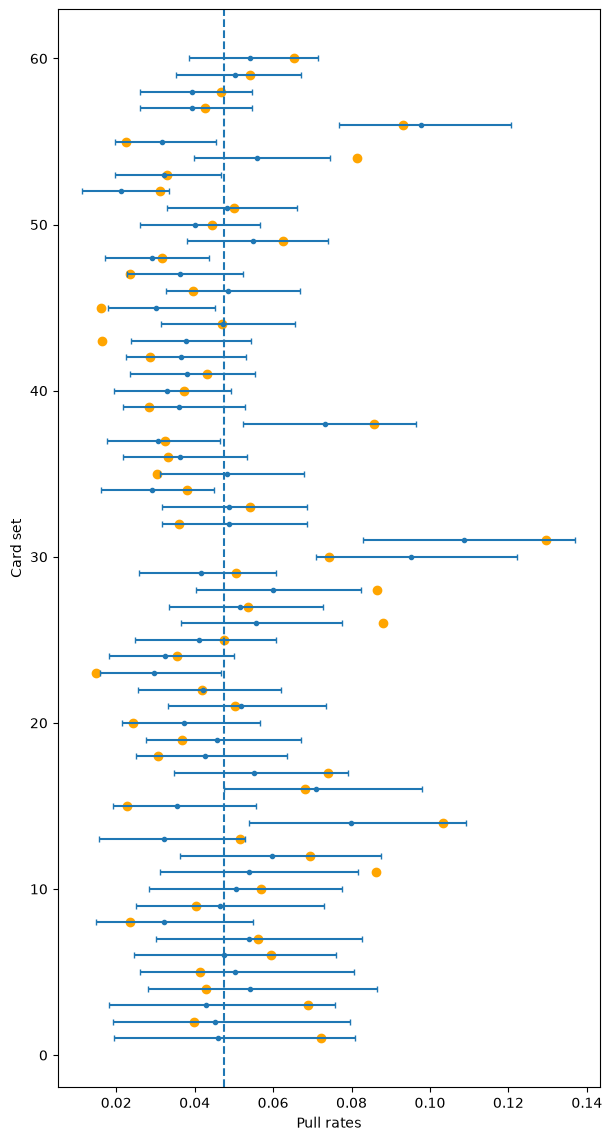

In [40]:
# 3.5.2 · Your code here
# Synthetic set dataframe construction
setID = np.arange(1, 61, 1)
sets = pd.DataFrame()

sets['setID'] = setID
sets['packs'] = rng.integers(3, 401, 60)
sets['true_pullrate'] = rng.beta(4, 76, 60)
sets['hits'] = rng.binomial(sets.packs, sets.true_pullrate)
sets['sim_rate'] = (sets.hits/sets.packs)
sets = sets.sort_values('packs', ascending = False)

#Fitting
def neg_log_lik(params, H, AB):
    log_a, log_b = params       
    a, b = np.exp(log_a), np.exp(log_b)
    bbsum = stats.betabinom.logpmf(H, AB, a, b).sum()
    return -bbsum           

res2 = optimize.minimize(neg_log_lik, x0=np.log([1, 10]), args=(sets.hits, sets.packs), method="Nelder-Mead")
alpha_pull, beta_pull = np.exp(res2.x)

#Updating
sets['eb_estimate'] = ((sets.hits+ alpha_pull) / (sets.packs + alpha_pull + beta_pull))
sets['alpha1'] = sets.hits + alpha_pull
sets['beta1'] = beta_pull + sets.packs - sets.hits
sets['low'] = stats.beta(sets.alpha1, sets.beta1).ppf(0.05)
sets['high'] = stats.beta(sets.alpha1, sets.beta1).ppf(0.95)

#Plotting
y = np.arange(len(sets), 0, -1)
xerr_CI = [sets.eb_estimate - sets.low,     
        sets.high - sets.eb_estimate]  

plt.figure(figsize=(7, 14))   # (width, height) in inches
plt.errorbar(sets.eb_estimate, y, xerr = xerr_CI, fmt="o", capsize=2, markersize = 3)
plt.scatter(sets.true_pullrate, y, color = 'orange')
plt.axvline(alpha_pull / (alpha_pull + beta_pull), ls="--")
plt.xlabel('Pull rates')
plt.ylabel('Card set')
plt.show()

In [41]:
inside = (sets.low <= sets.true_pullrate) & (sets.true_pullrate <= sets.high)
print(f"{inside.sum()} of {len(sets)} intervals contain the true rate ({inside.mean():.0%})")

52 of 60 intervals contain the true rate (87%)


## References

- *Introduction to Empirical Bayes: Examples from Baseball Statistics*, David Robinson (2017), Chapter 4.
- Brown, Cai & DasGupta (2001), "Interval estimation for a binomial proportion", *Statistical Science* 16(2).
- Cross Validated, on credible vs confidence intervals: https://stats.stackexchange.com/questions/2272